# Perturbation Analysis
This notebook performs differential expression analysis and visualizes perturbation effects using the preprocessed Jurkat dataset.

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sc.settings.verbosity = 3
sc.set_figure_params(dpi=80, facecolor='white')

In [2]:
import os
if os.path.exists('processed_adata.h5ad'):
    adata = sc.read_h5ad('processed_adata.h5ad')
    print(adata)
else:
    print("Error: processed_adata.h5ad not found. Please run zyt/data_analysis.ipynb first.")

AnnData object with n_obs × n_vars = 21412 × 18080
    obs: 'UMI_count', 'batch_var', 'cell_barcode', 'cell_type', 'gem_group', 'gene', 'gene_id', 'gene_transcript', 'mitopercent', 'sgID_AB', 'target_gene', 'transcript', 'z_gemgroup_UMI'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p'
    obsm: 'X_umap'


## Perturbation Analysis (Differential Expression)
Identify how each gene perturbation affects the transcriptomic state. This must be run before visualization to identify key targets.

Analyzing treatments against non-targeting control.
ranking genes
--> Few observations in a group for normal approximation (<=25). Lower test accuracy.
--> Few observations in a group for normal approximation (<=25). Lower test accuracy.
--> Few observations in a group for normal approximation (<=25). Lower test accuracy.


/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:

--> Few observations in a group for normal approximation (<=25). Lower test accuracy.


/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:

--> Few observations in a group for normal approximation (<=25). Lower test accuracy.


/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:

    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:01:18)


/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:457: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:459: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/yuntao/AIML/CS271-Project/.venv/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:

Top 5 perturbations by number of DE genes: ['MAU2', 'DNMT1', 'MAX', 'SMARCE1', 'SDC1']


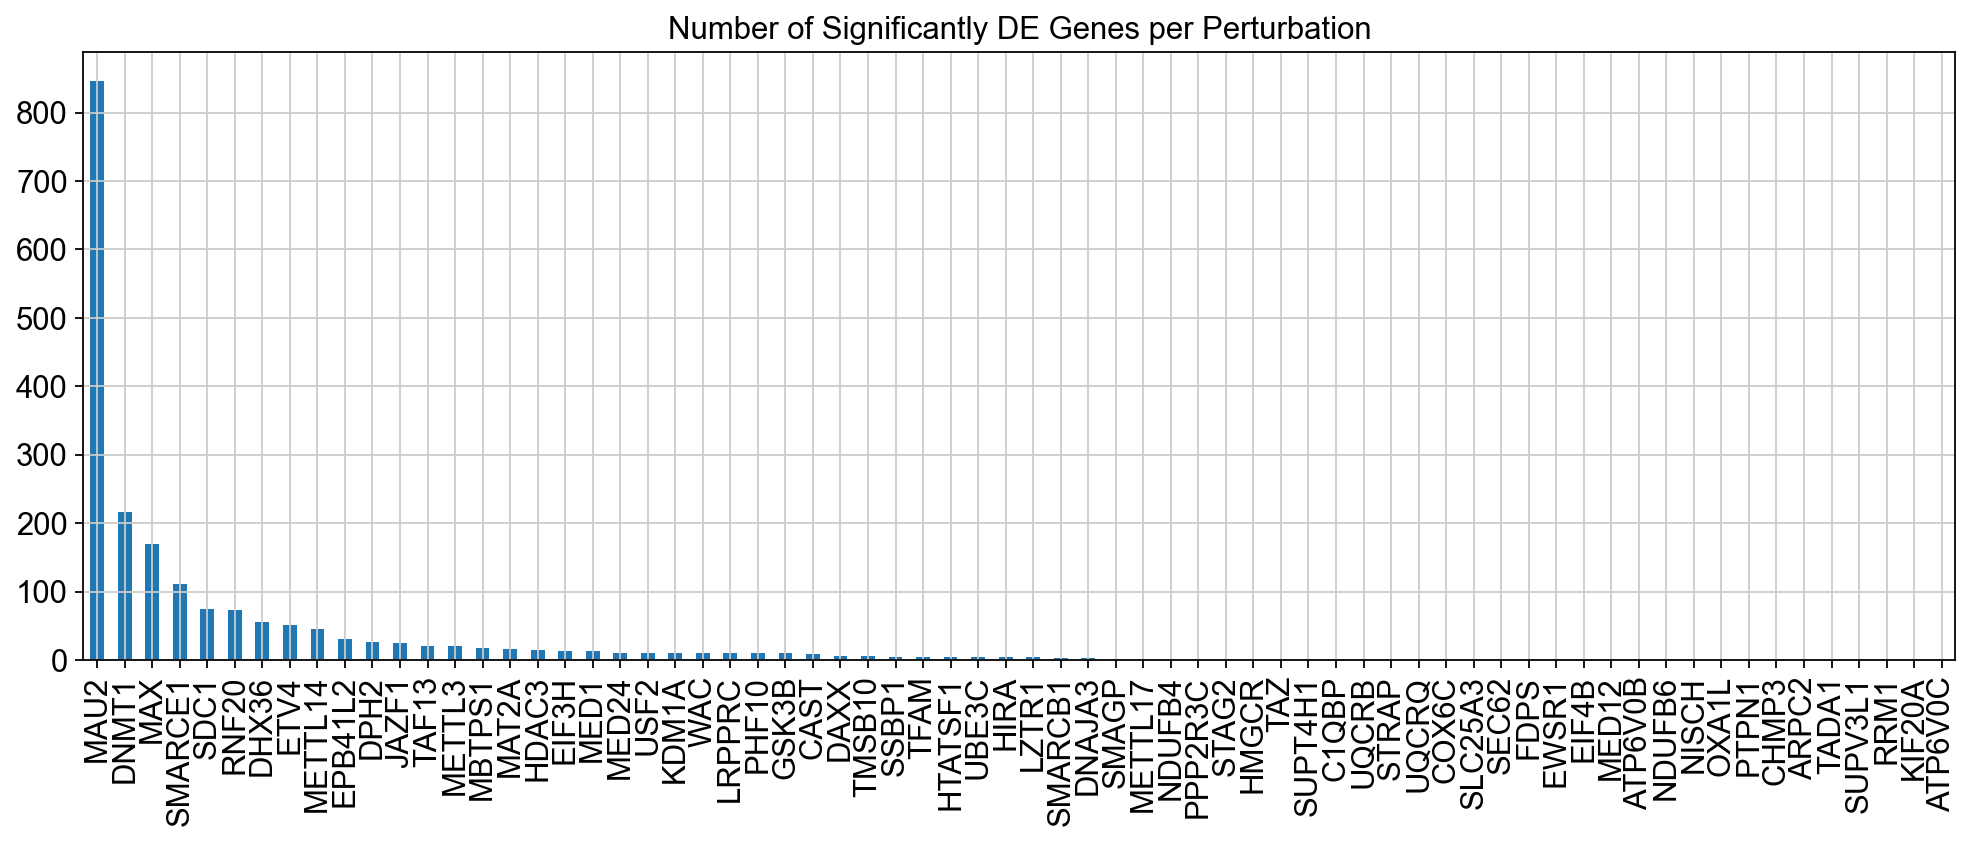

In [3]:
control_label = 'non-targeting'
target_genes = [g for g in adata.obs['target_gene'].cat.categories if g != control_label]

print(f"Analyzing treatments against {control_label} control.")
sc.tl.rank_genes_groups(adata, groupby='target_gene', reference=control_label, method='wilcoxon')

res_all = sc.get.rank_genes_groups_df(adata, group=None)
sig_de = res_all[(res_all['logfoldchanges'].abs() > 1.0) & (res_all['pvals_adj'] < 0.05)]
de_counts = sig_de.groupby('group', observed=False).size().to_dict()

top_5_perturbations = sorted(de_counts, key=de_counts.get, reverse=True)[:5]
print("Top 5 perturbations by number of DE genes:", top_5_perturbations)

plt.figure(figsize=(15, 5))
pd.Series(de_counts).sort_values(ascending=False).plot(kind='bar')
plt.title('Number of Significantly DE Genes per Perturbation')
plt.show()

## Knockdown Efficiency Visualization

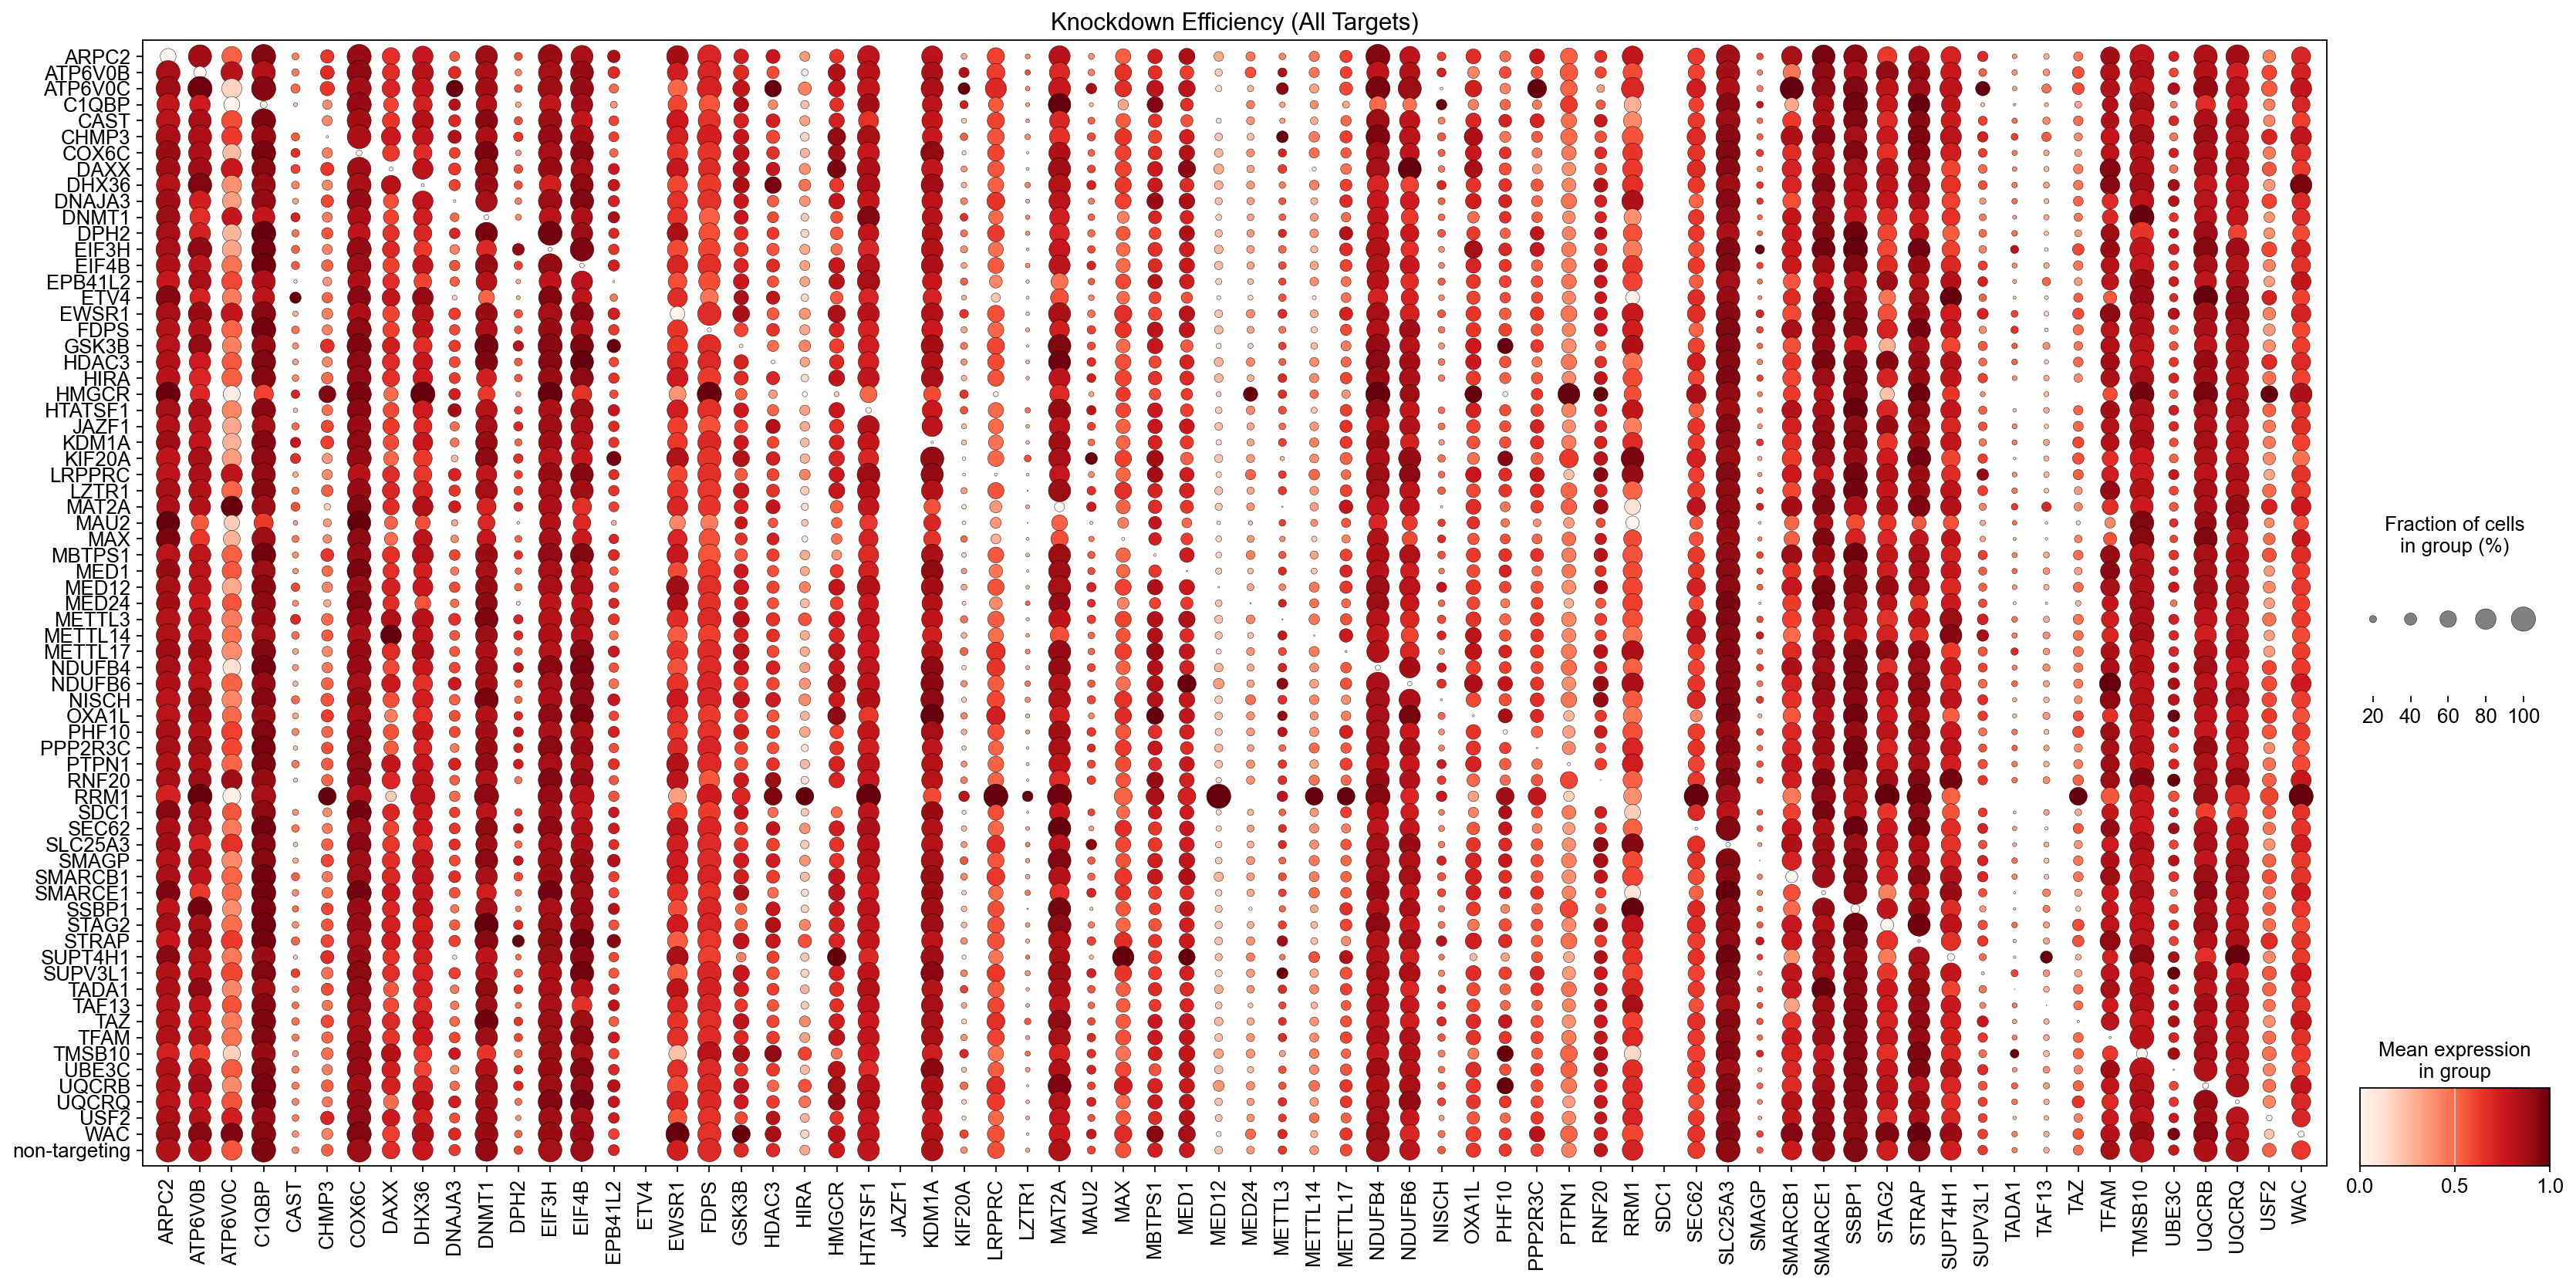

In [4]:
available_targets = [g for g in target_genes if g in adata.var_names]
dotplot_genes = [g for g in adata.obs['target_gene'].cat.categories if g in available_targets]

sc.pl.dotplot(adata, dotplot_genes, groupby='target_gene', \n",
              standard_scale='var', figsize=(25, 12))

## Visualizing Results on UMAP

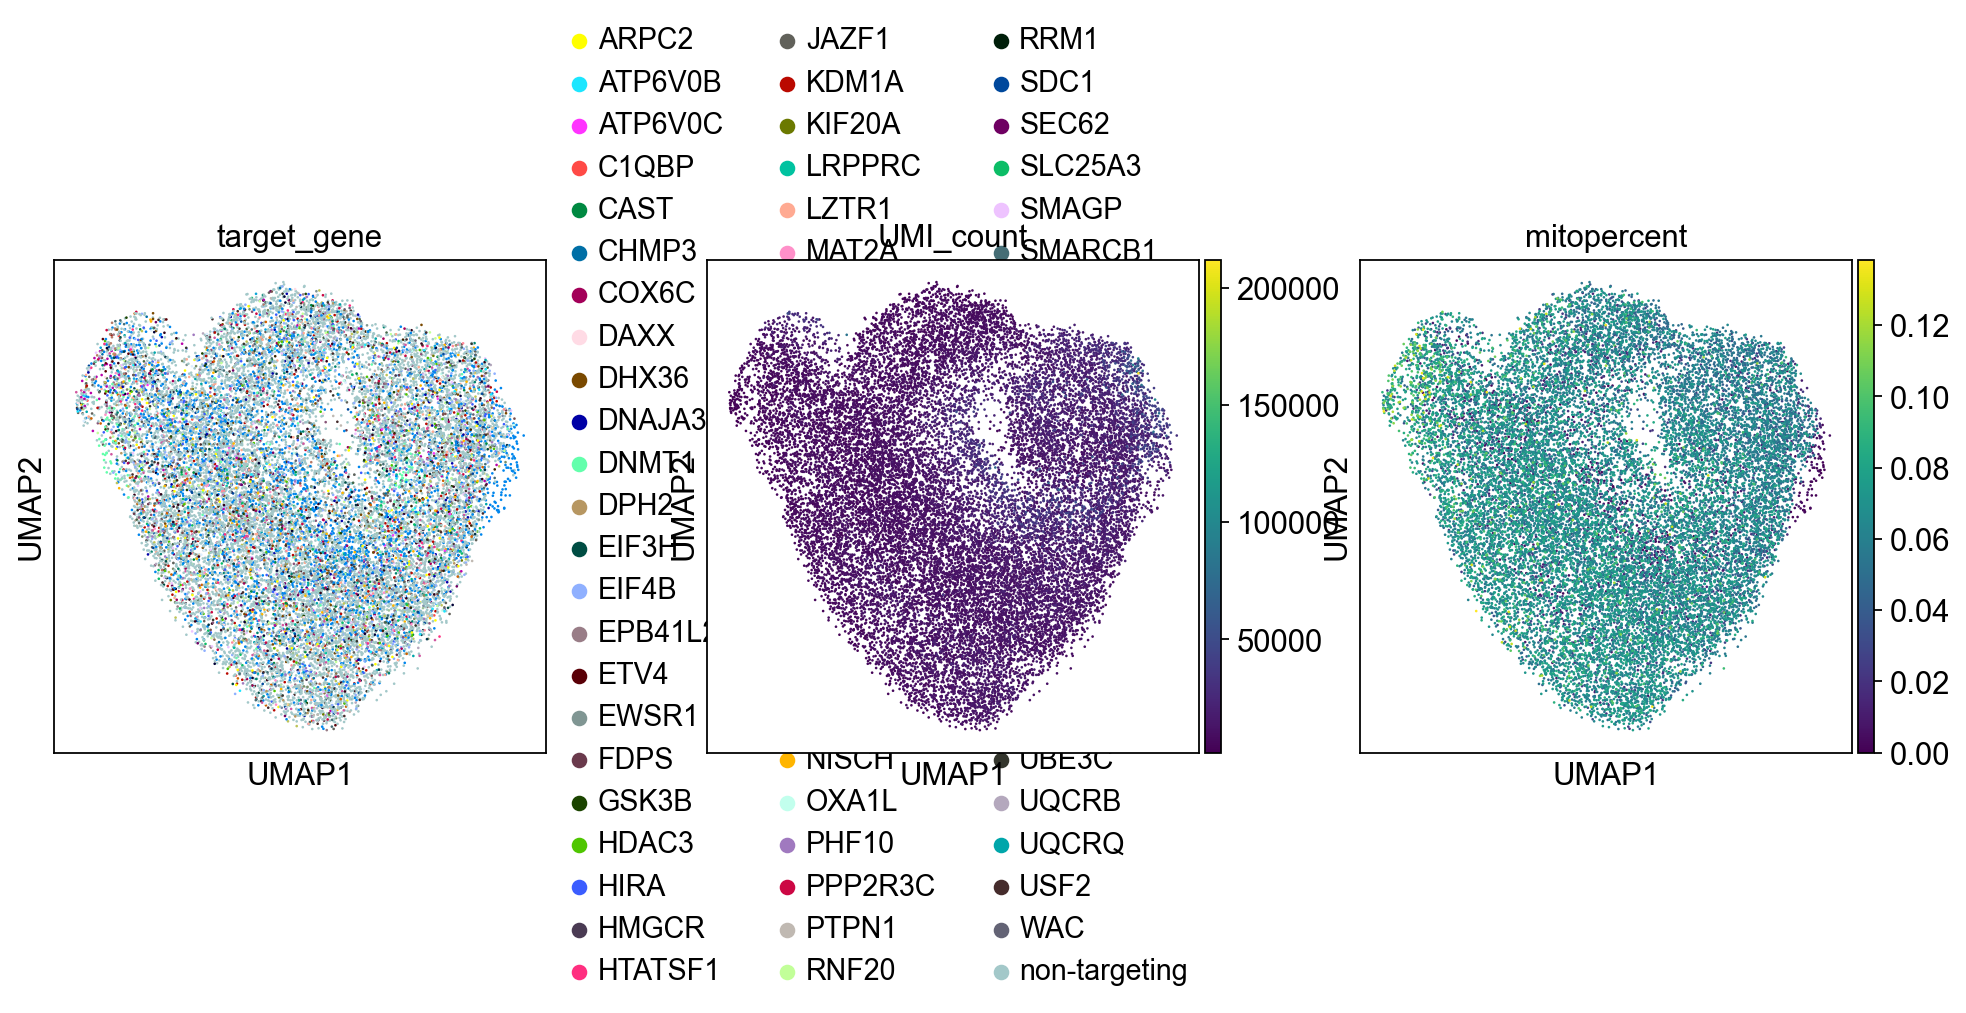

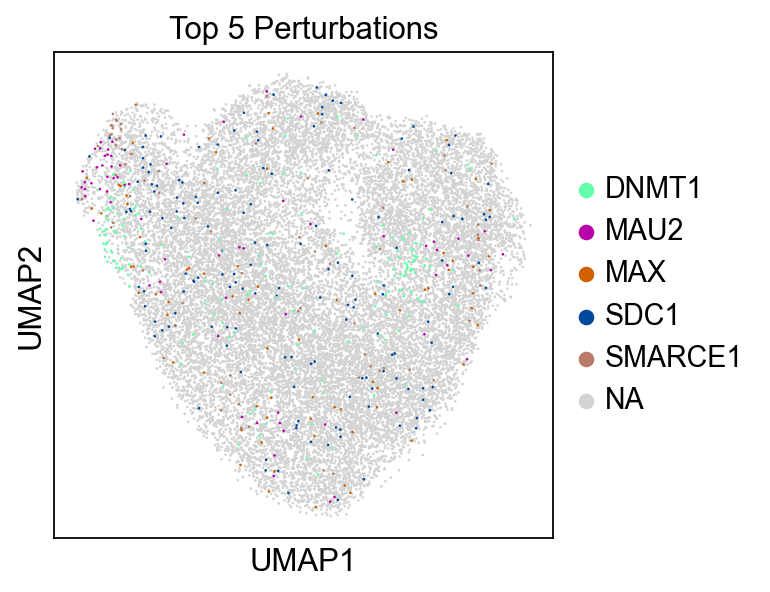

computing PCA
    with n_comps=50


/var/folders/t1/md26m3vs5mldtk18qm327l6h0000gp/T/ipykernel_63431/3203901687.py:3: UserWarning: You’re trying to run this on 18080 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  sc.pl.rank_genes_groups_matrixplot(adata, n_genes=5, groups=top_5_perturbations, groupby='target_gene', standard_scale='var')


    finished (0:00:02)
Storing dendrogram info using `.uns['dendrogram_target_gene']`
categories: ARPC2, ATP6V0B, ATP6V0C, etc.
var_group_labels: MAU2, DNMT1, MAX, etc.


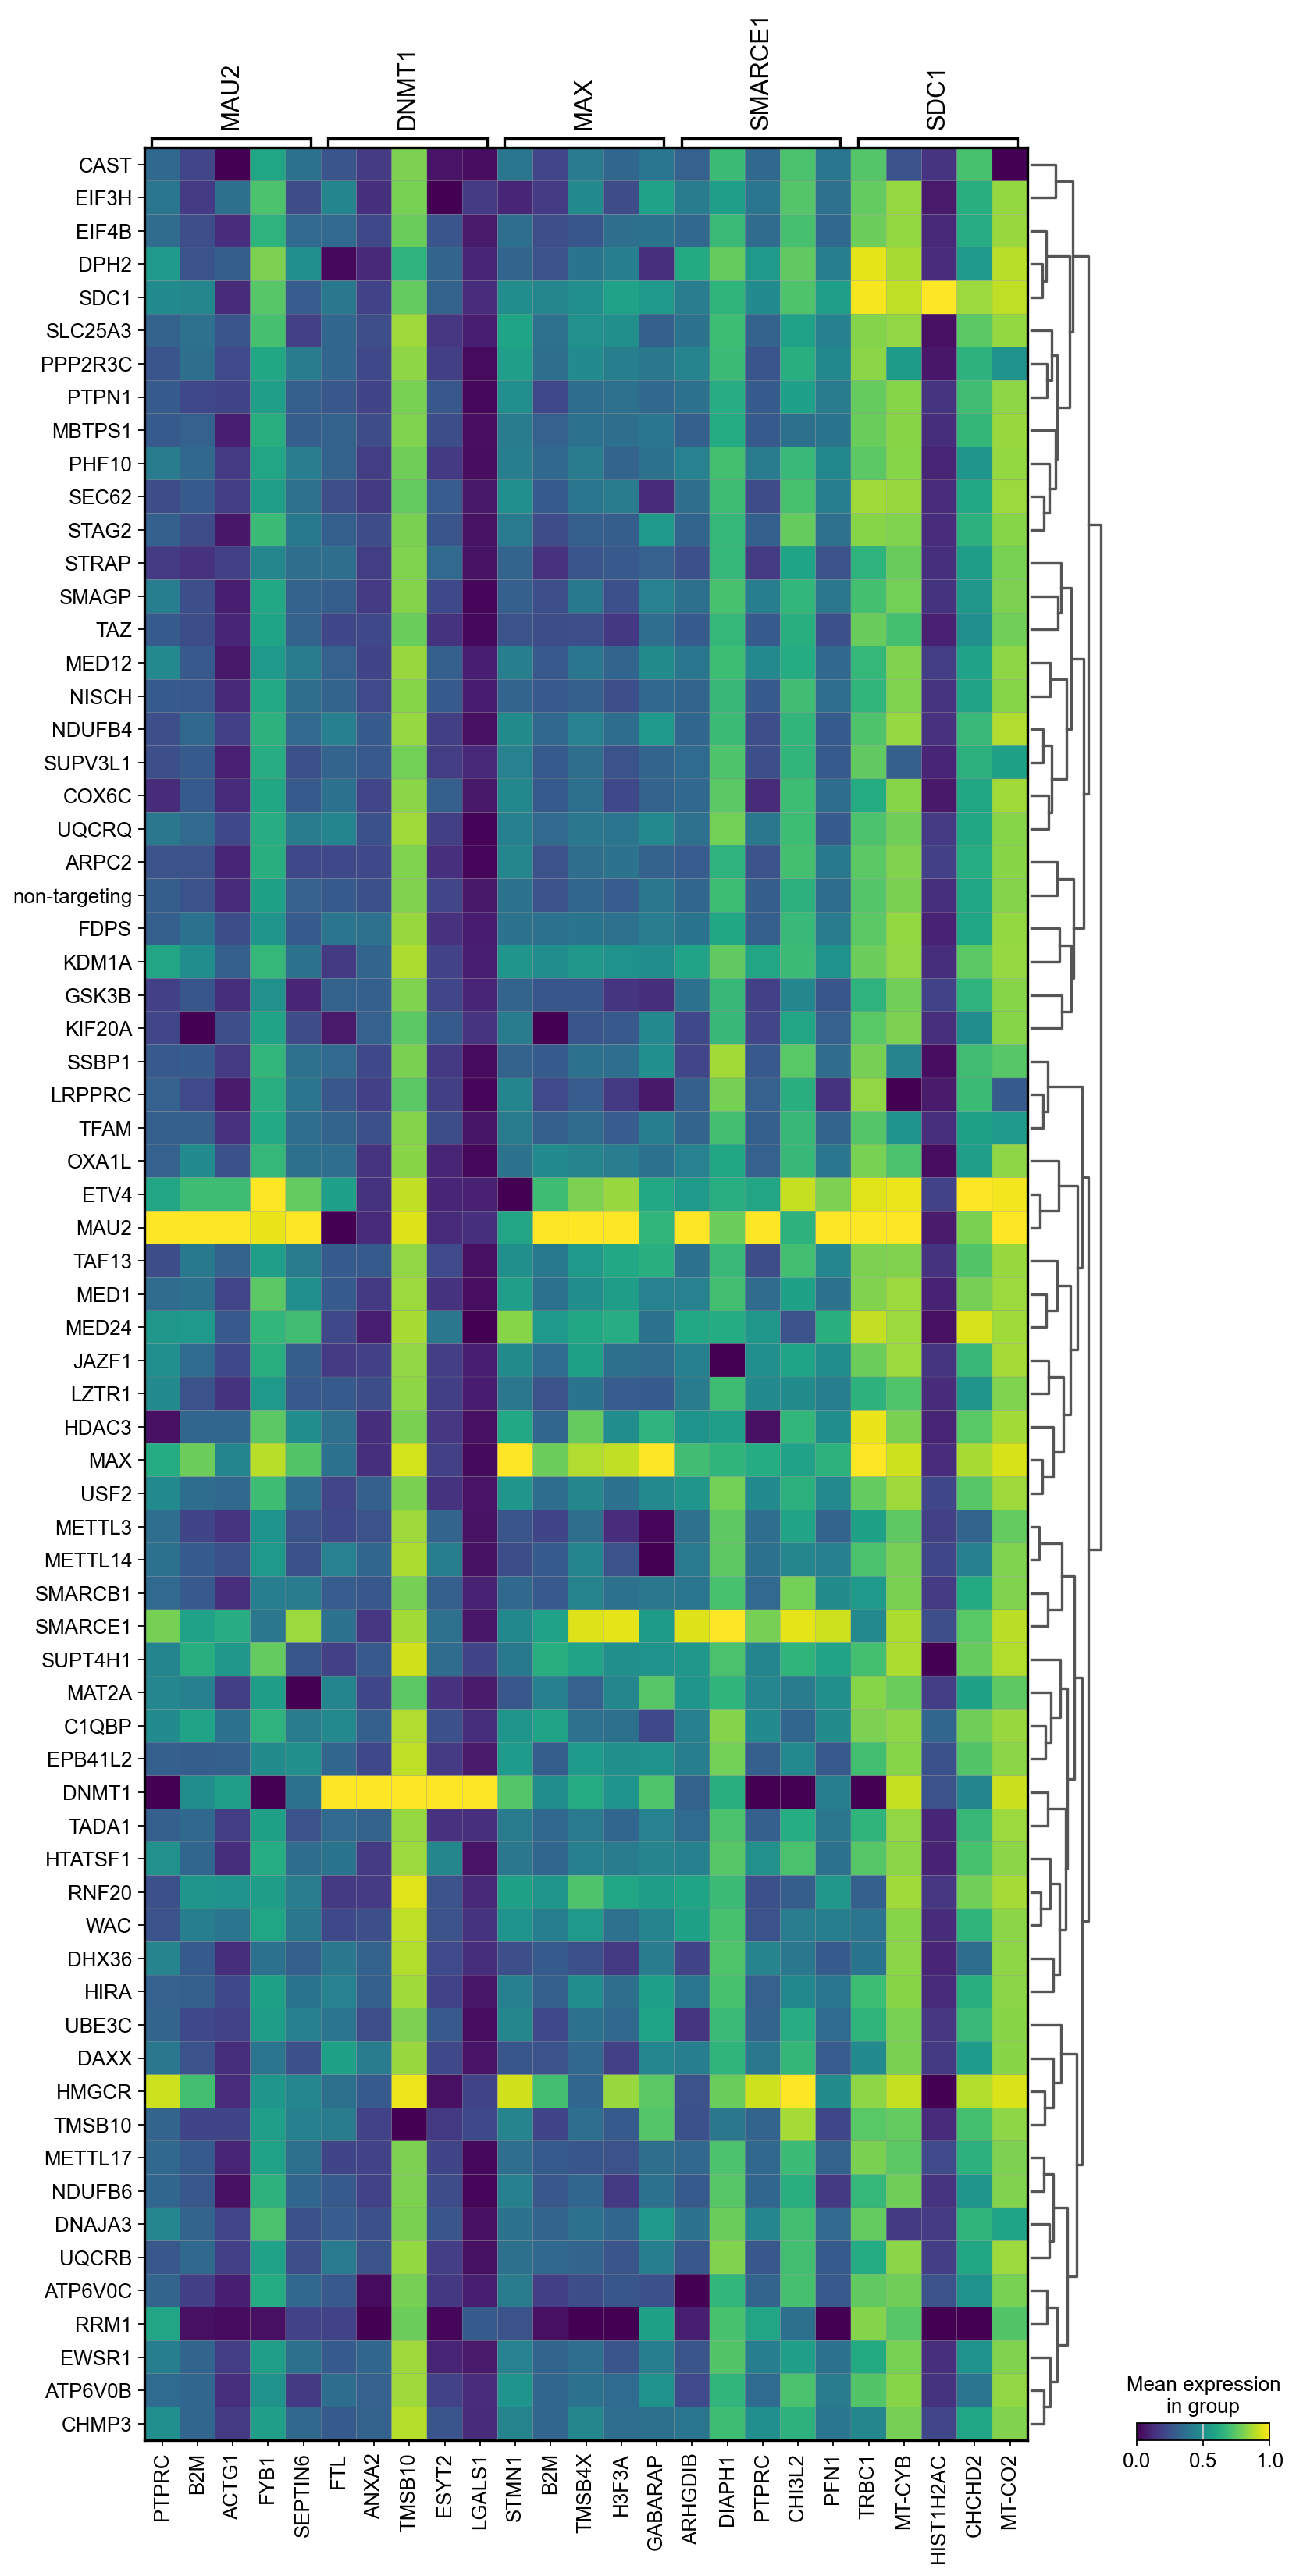

In [5]:
sc.pl.umap(adata, color=['target_gene', 'UMI_count', 'mitopercent'])
sc.pl.umap(adata, color=['target_gene'], groups=top_5_perturbations, title='Top 5 Perturbations')
sc.pl.rank_genes_groups_matrixplot(adata, n_genes=5, groups=top_5_perturbations, groupby='target_gene', standard_scale='var')

## Quantitative Knockdown Analysis
Evaluate knockdown percentage using `.raw` linear-scale expression.

In [6]:
def calculate_kd_metrics(adata, control_label='non-targeting'):
    results = []
    target_genes_list = [g for g in adata.obs['target_gene'].cat.categories if g != control_label]
    
    for gene in target_genes_list:
        if gene not in adata.raw.var_names:
            continue
            
        control_idx = adata.obs['target_gene'] == control_label
        treated_idx = adata.obs['target_gene'] == gene
        
        gene_idx = adata.raw.var_names.get_loc(gene)
        control_exp = adata.raw.X[control_idx, gene_idx]
        treated_exp = adata.raw.X[treated_idx, gene_idx]
        
        if hasattr(control_exp, 'toarray'):
            control_exp = control_exp.toarray().flatten()
            treated_exp = treated_exp.toarray().flatten()
            
        control_lin = np.expm1(control_exp)
        treated_lin = np.expm1(treated_exp)
        
        mean_control = np.mean(control_lin)
        mean_treated = np.mean(treated_lin)
        kd_perc = (1 - mean_treated / mean_control) * 100 if mean_control > 0 else 0
        
        results.append({
            'gene': gene,
            'mean_control': mean_control,
            'mean_treated': mean_treated,
            'kd_efficiency_pct': kd_perc
        })
        
    return pd.DataFrame(results).sort_values('kd_efficiency_pct', ascending=False)

kd_stats = calculate_kd_metrics(adata)
print(kd_stats.head(10))

       gene  mean_control  mean_treated  kd_efficiency_pct
11     DPH2      0.569212      0.000000         100.000000
4      CAST      0.418721      0.000000         100.000000
45    RNF20      1.161987      0.006486          99.441795
50    SMAGP      0.347425      0.011452          96.703629
48    SEC62      1.770058      0.067945          96.161446
55    STRAP      3.297946      0.136405          95.863945
41    OXA1L      1.330044      0.062758          95.281548
24    KDM1A      3.257830      0.155135          95.238075
61     TFAM      2.239329      0.112327          94.983902
43  PPP2R3C      1.048572      0.054376          94.814316


## Visualizing Knockdown Distribution Across Cells
Showing overall efficiency for all perturbations and the spread across individual cells.

Full Knockdown Statistics for All Perturbations:


,gene,mean_control,mean_treated,kd_efficiency_pct
11,DPH2,0.569212,0.000000,100.000000
4,CAST,0.418721,0.000000,100.000000
45,RNF20,1.161987,0.006486,99.441795
50,SMAGP,0.347425,0.011452,96.703629
48,SEC62,1.770058,0.067945,96.161446
55,STRAP,3.297946,0.136405,95.863945
41,OXA1L,1.330044,0.062758,95.281548
24,KDM1A,3.257830,0.155135,95.238075
61,TFAM,2.239329,0.112327,94.983902
43,PPP2R3C,1.048572,0.054376,94.814316


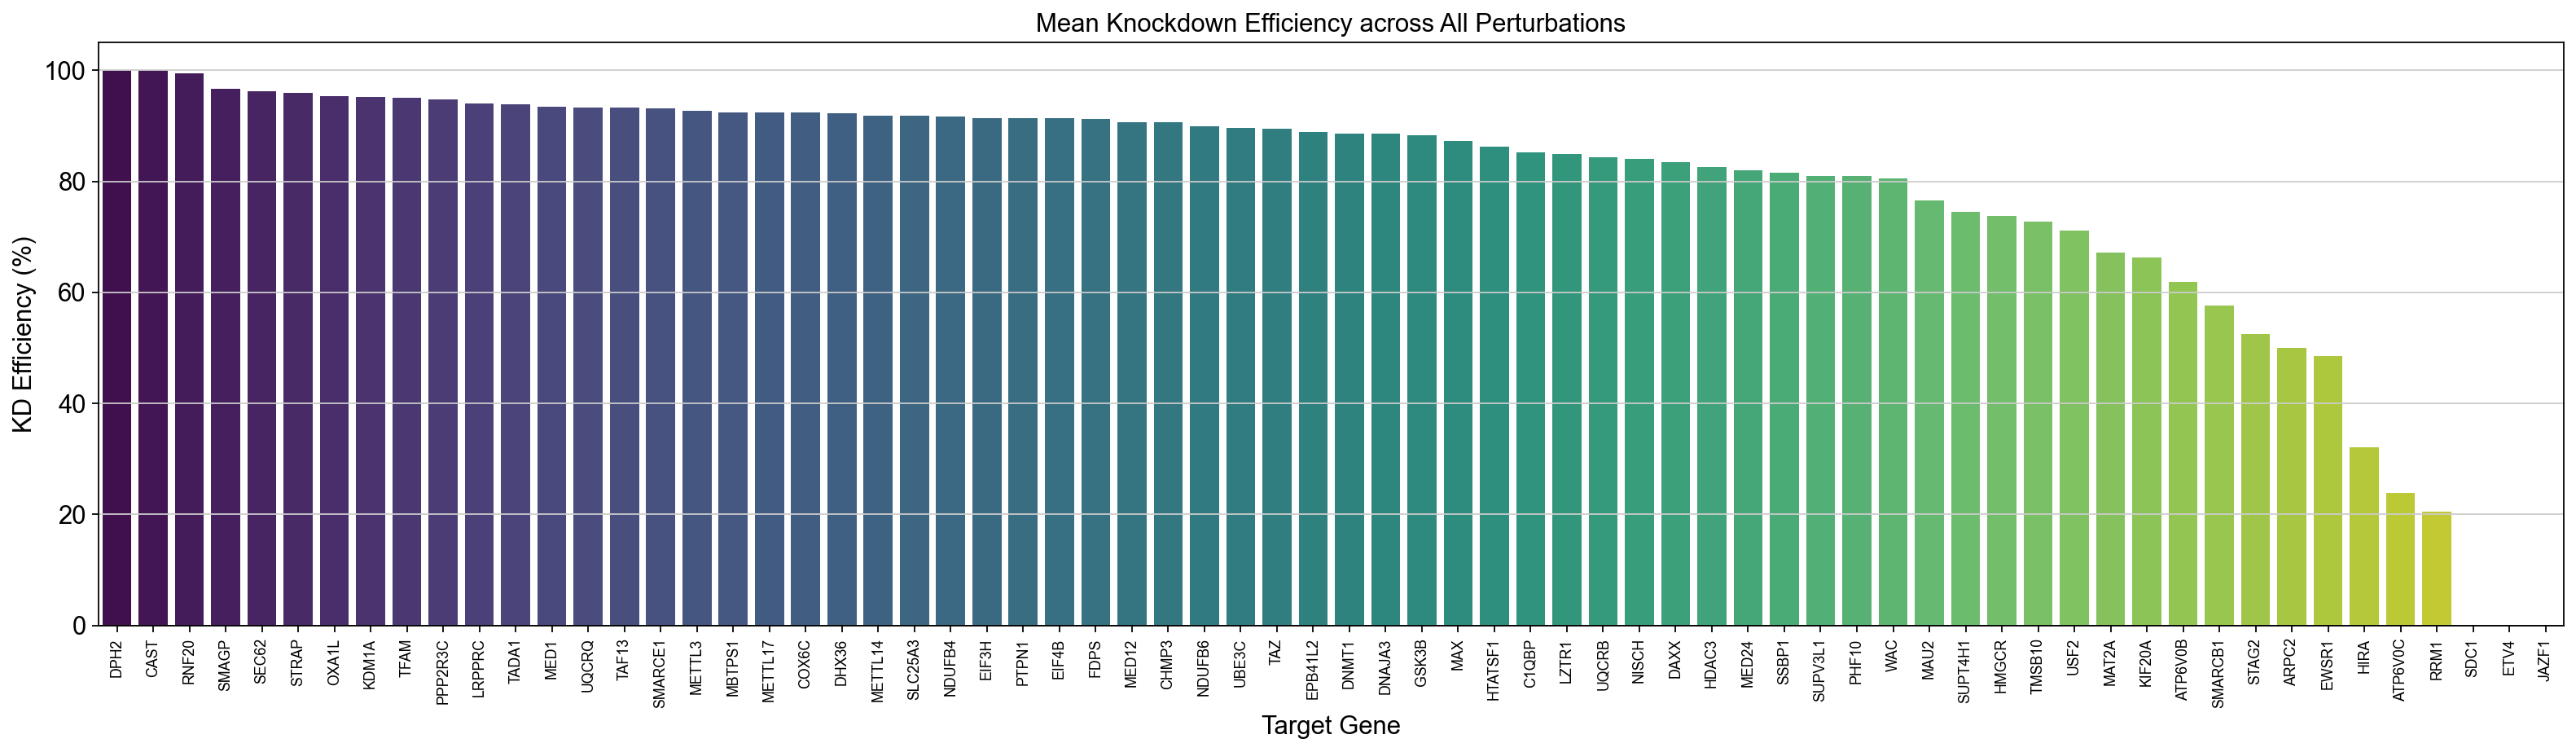

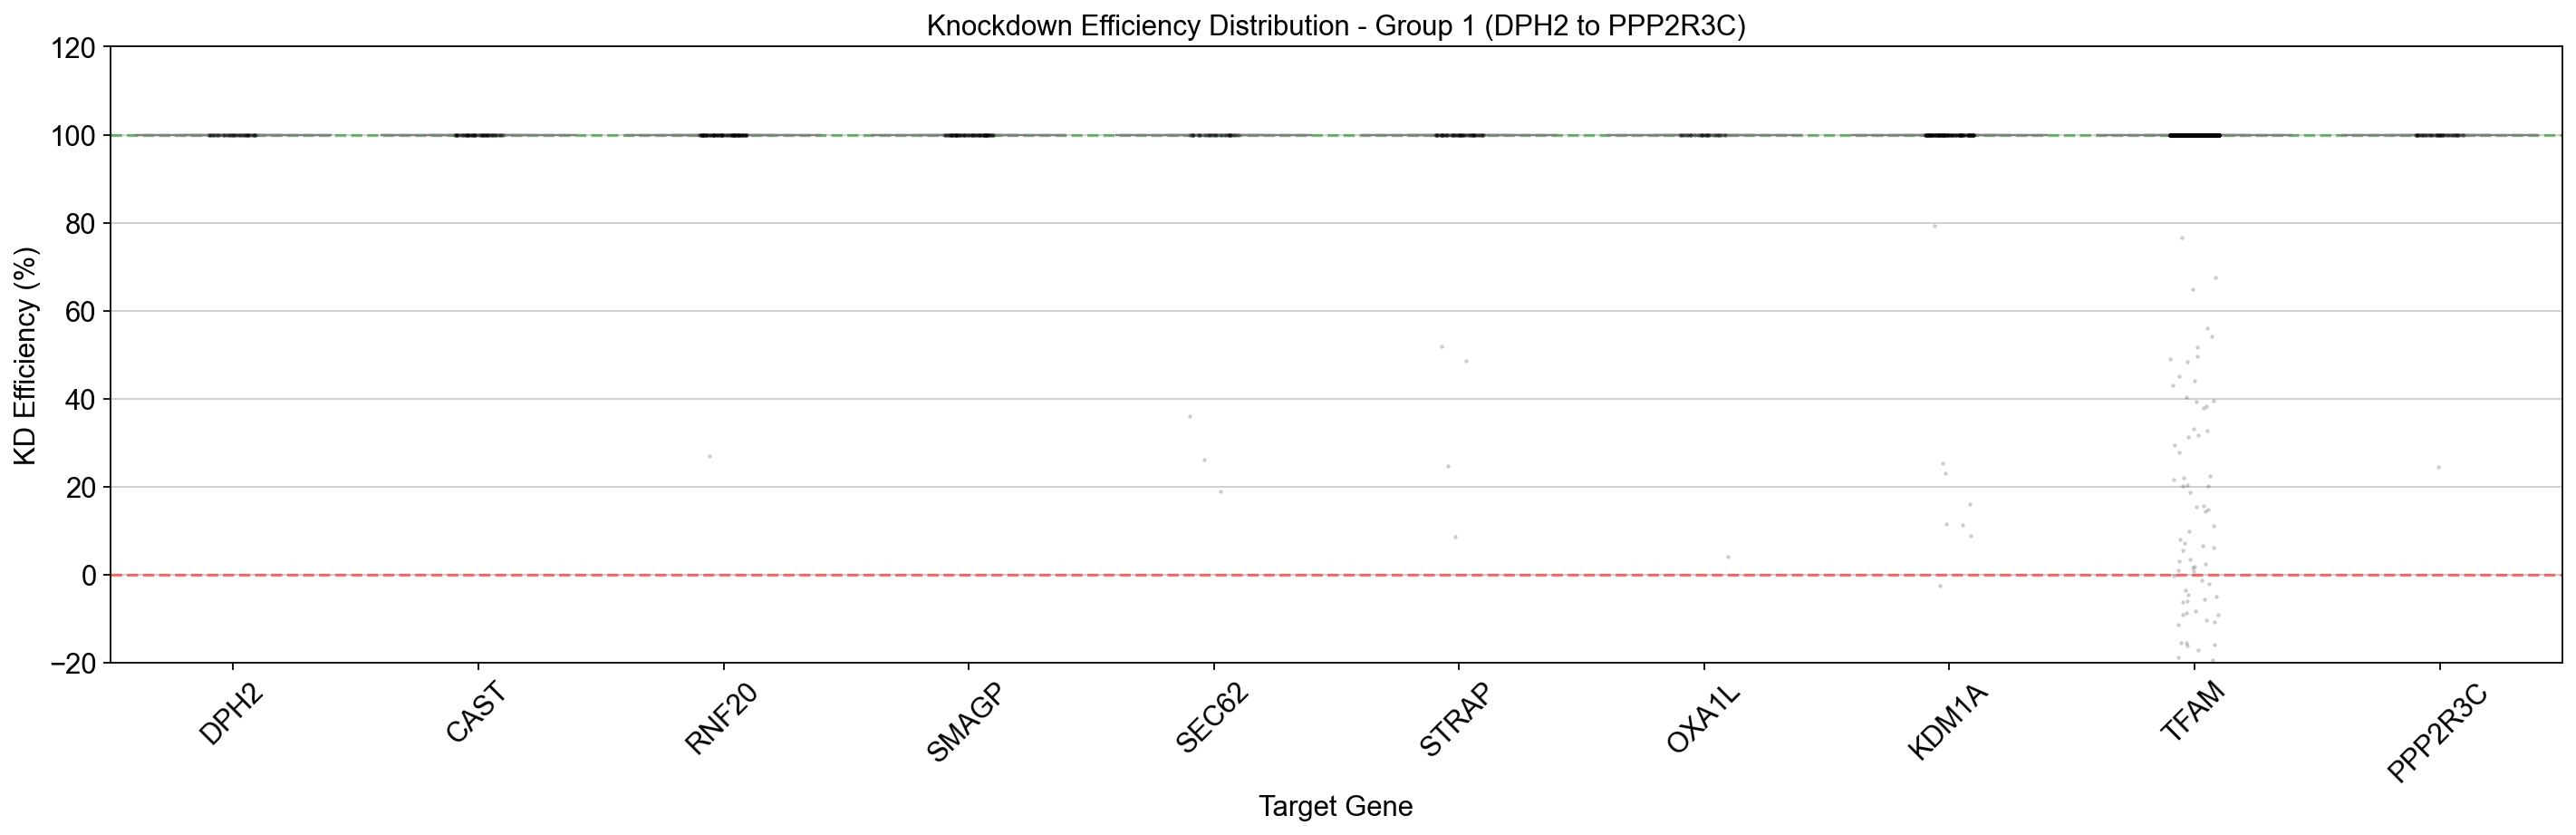

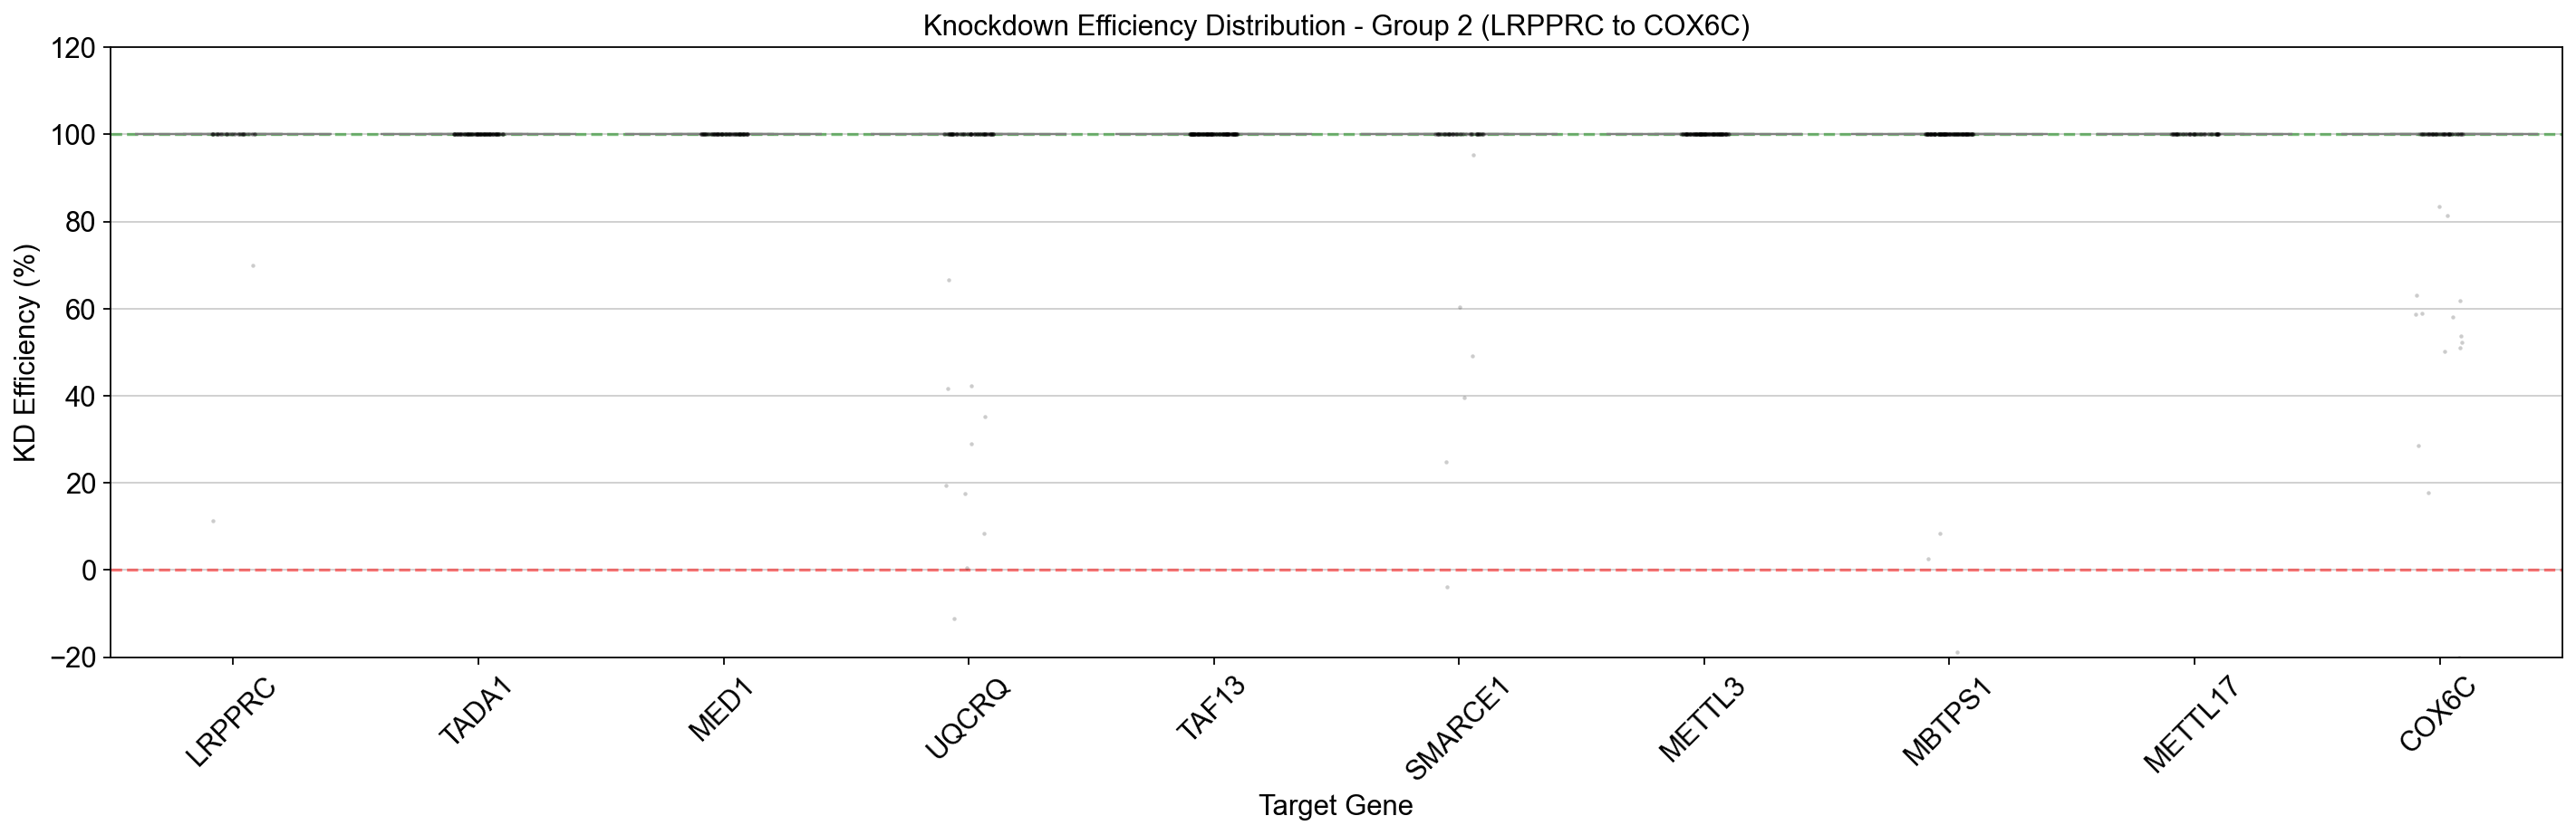

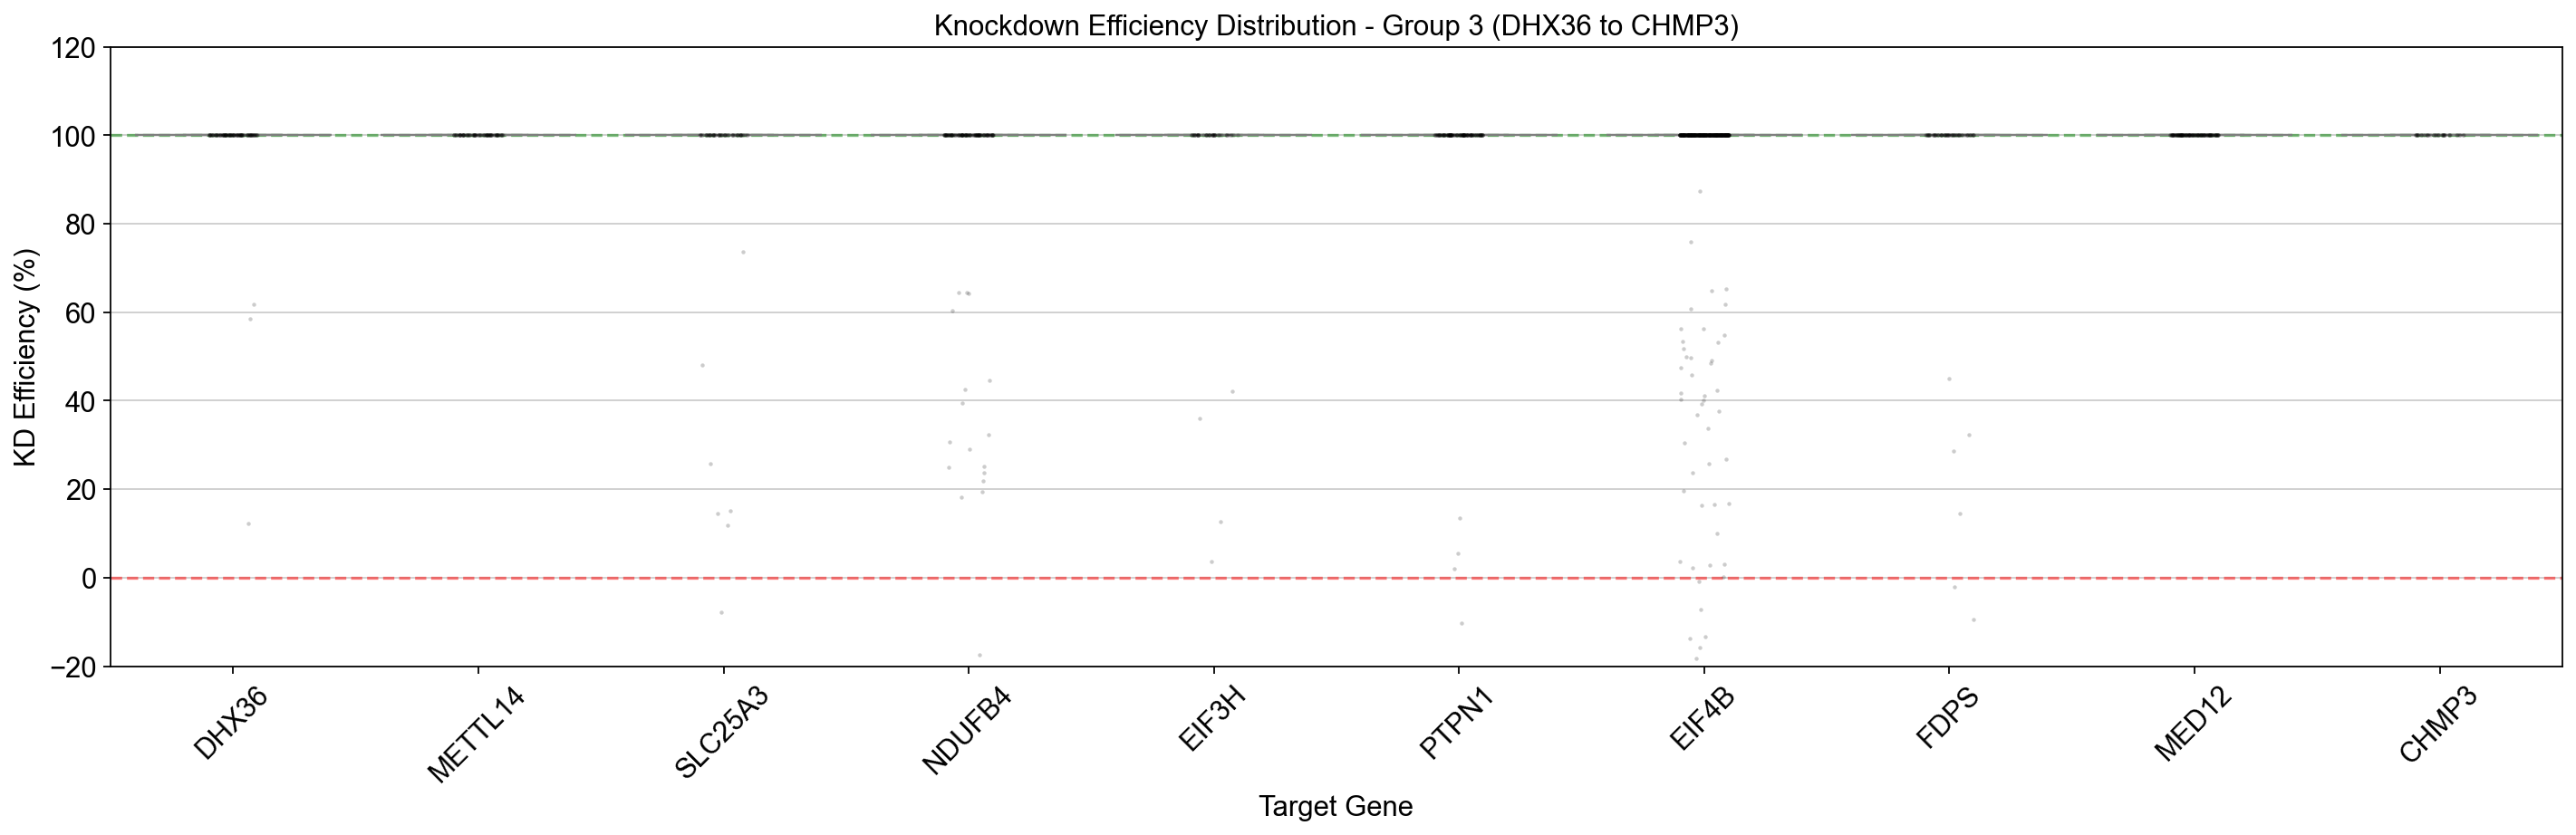

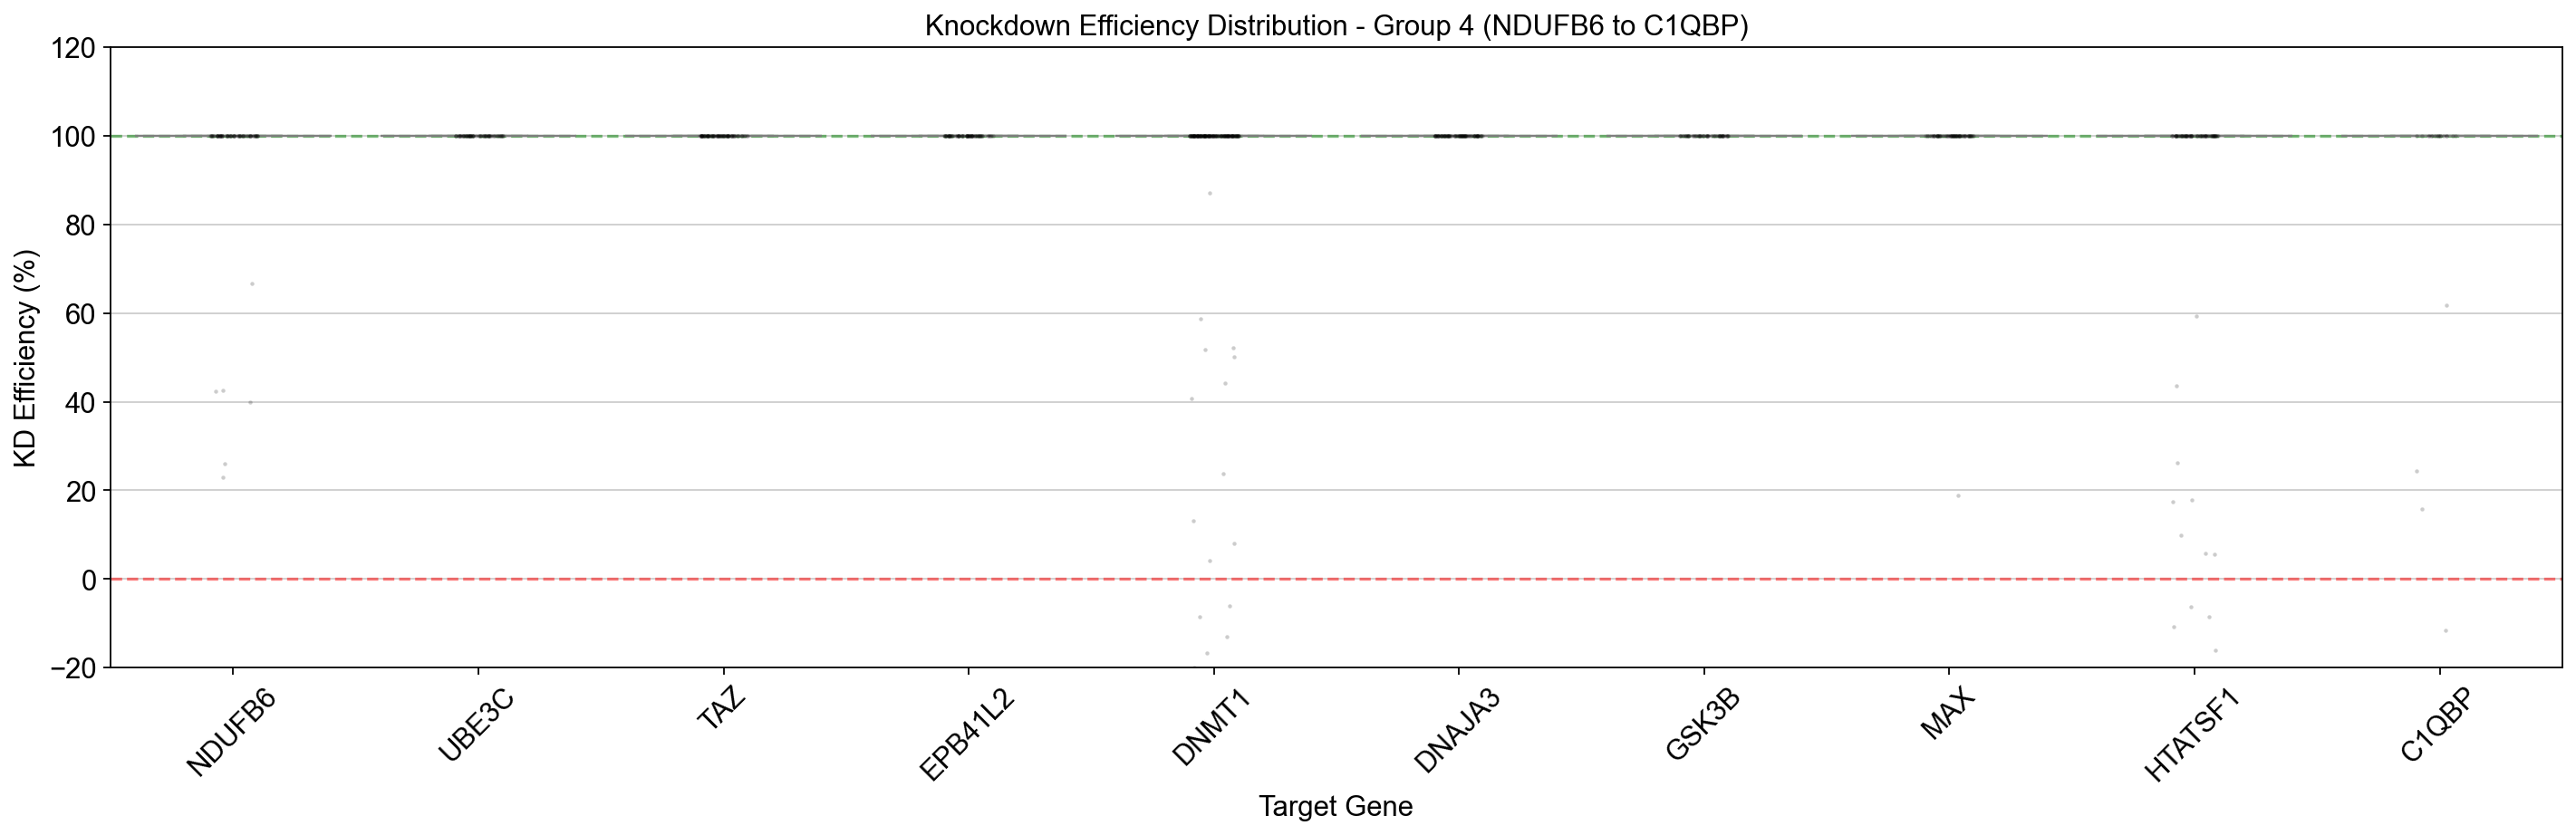

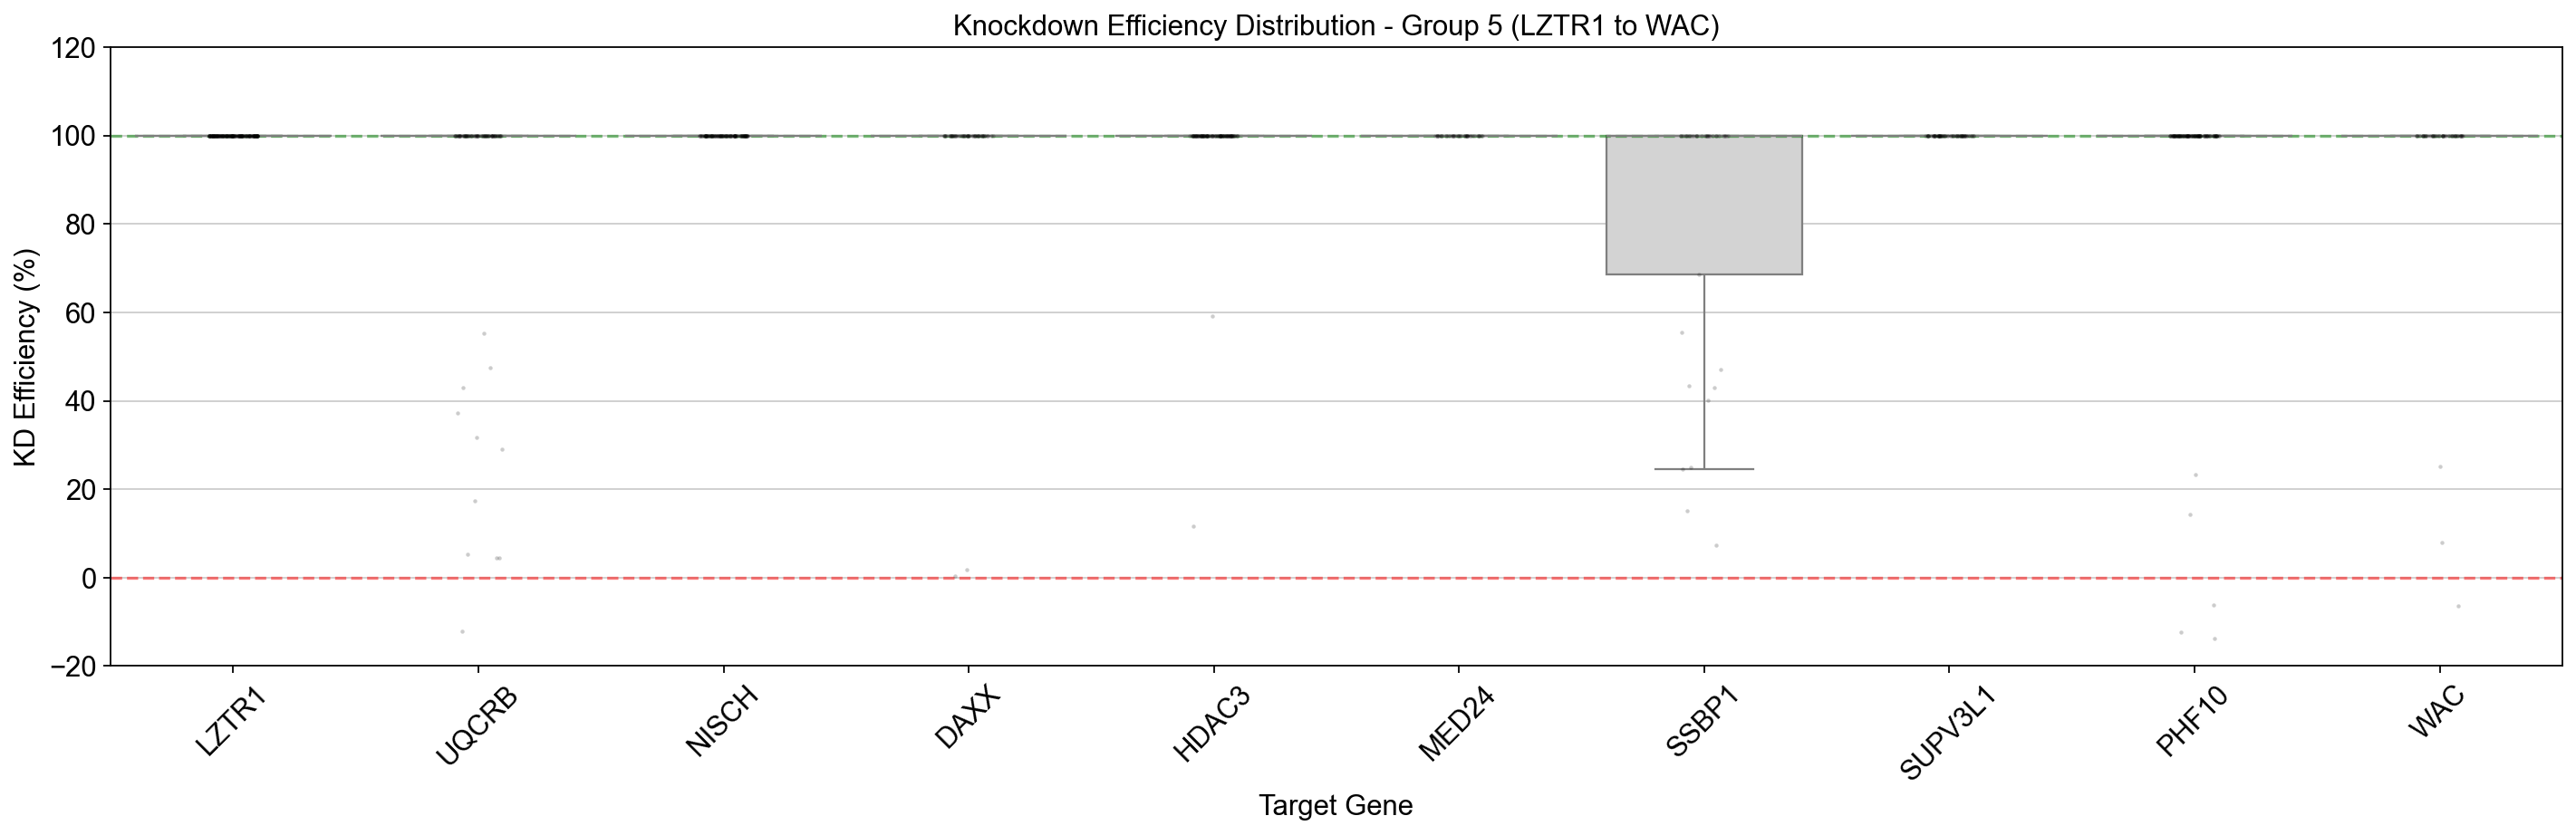

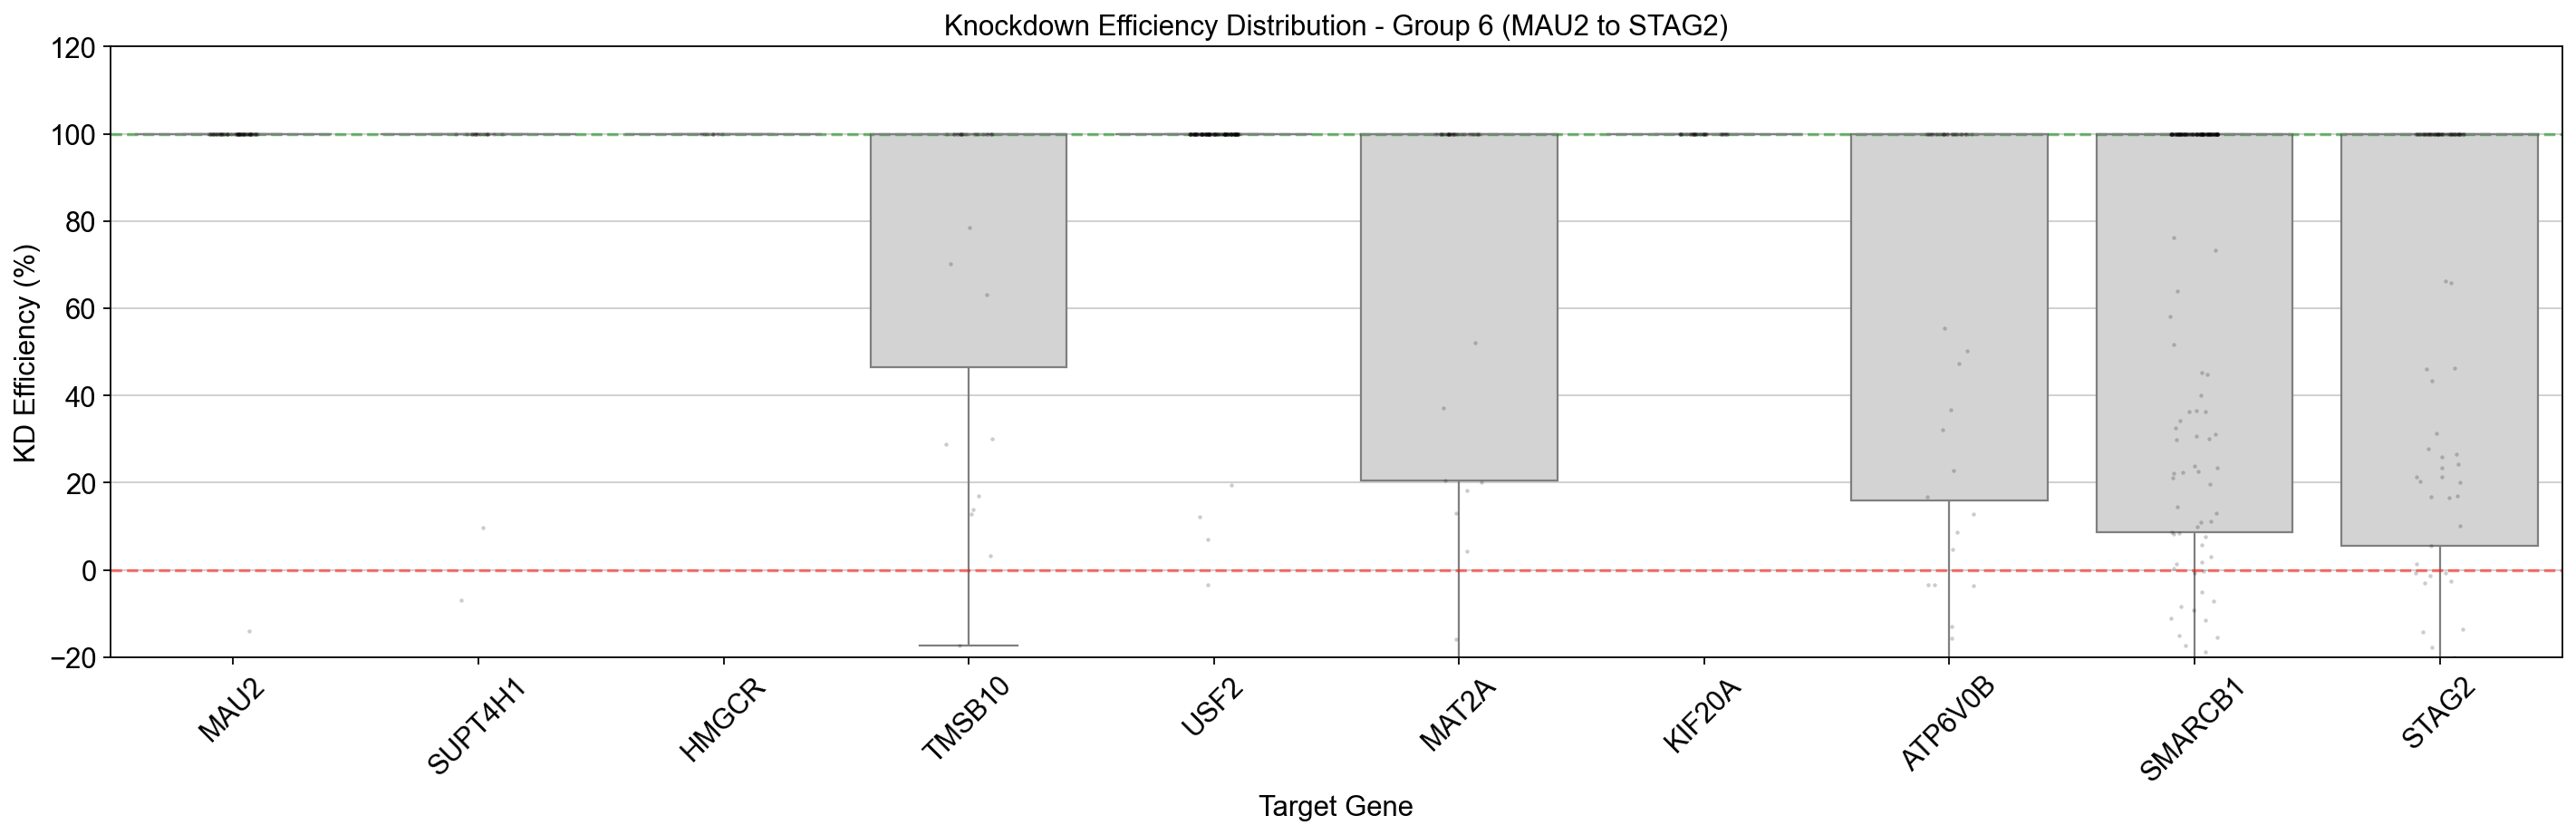

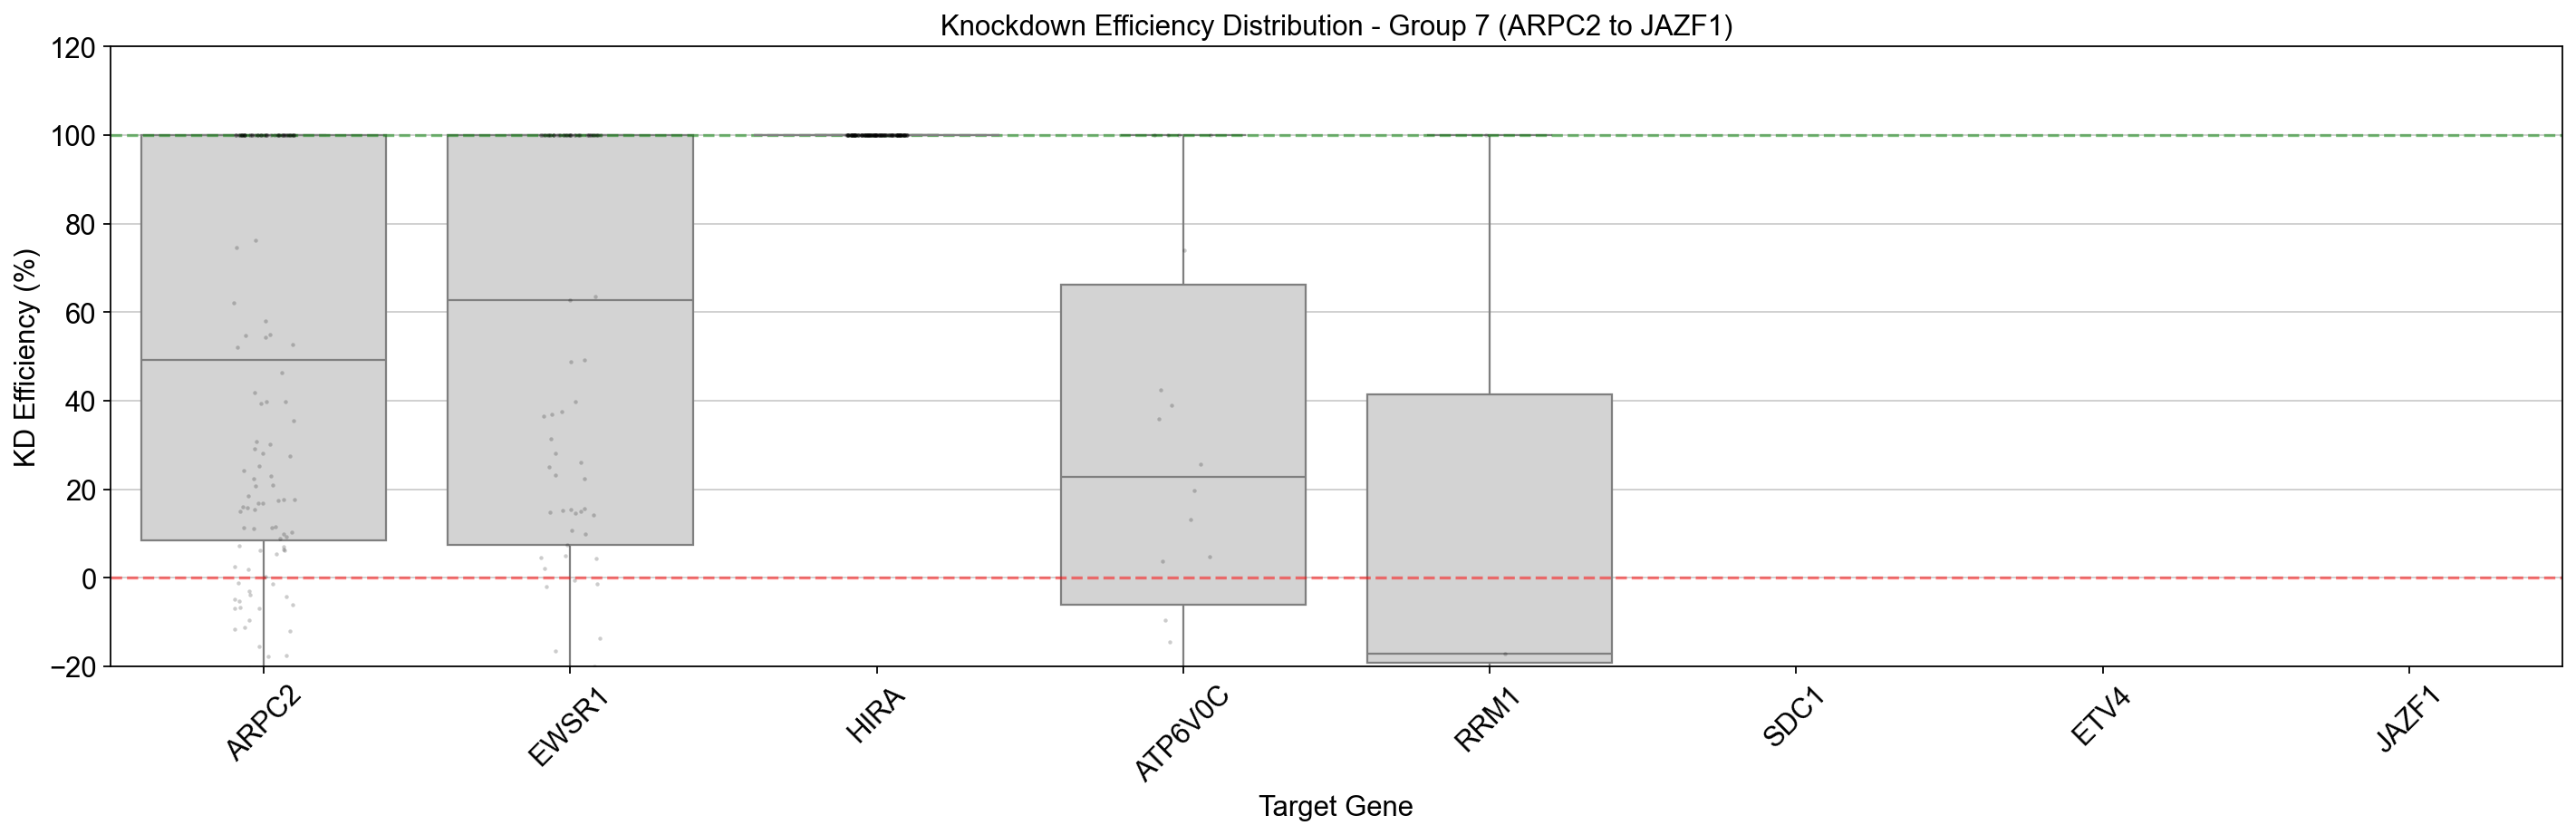

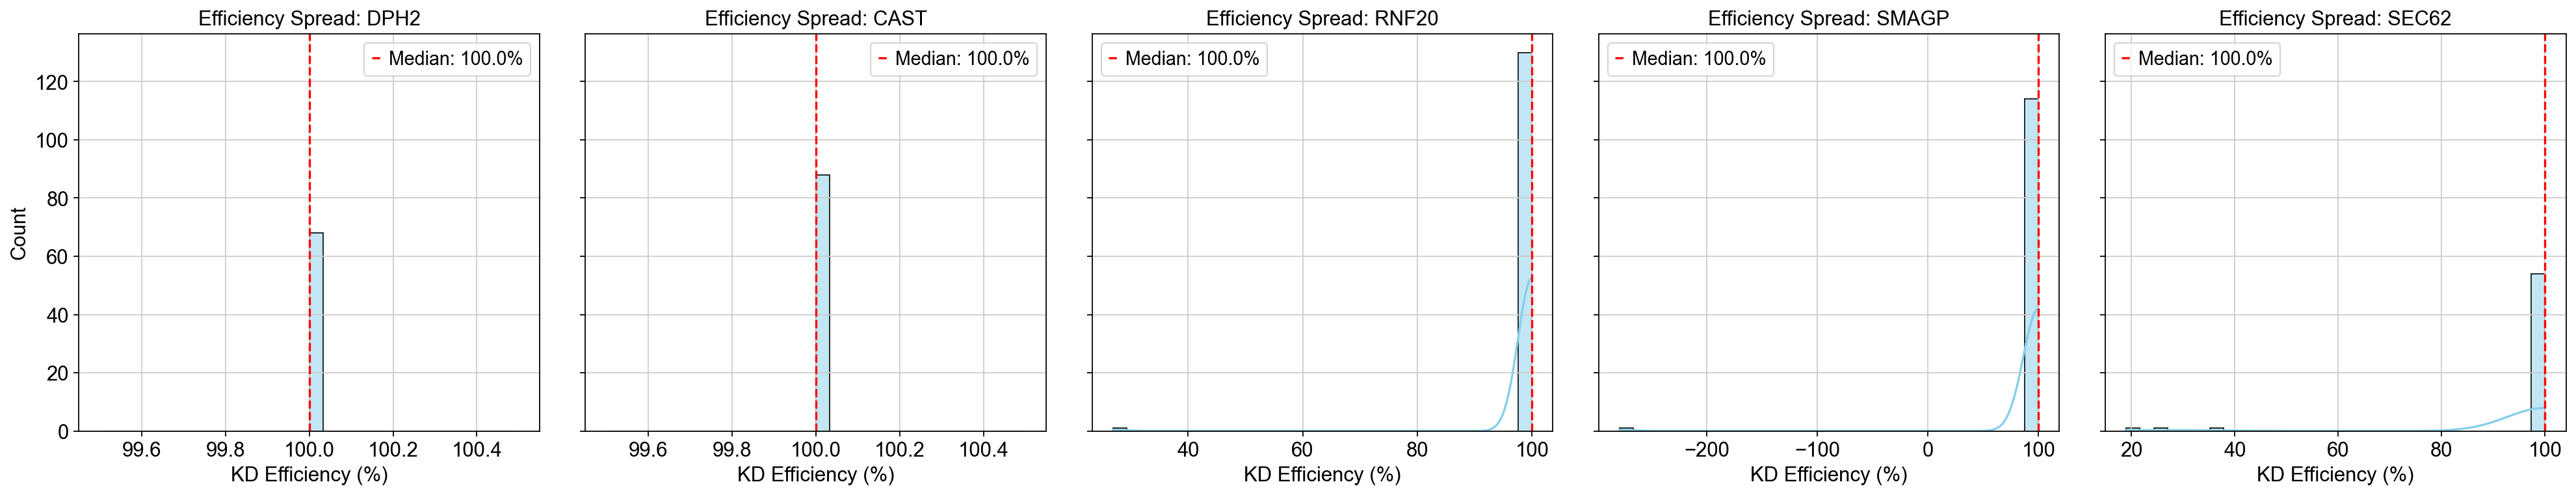

In [7]:
# 1. Show statistics for all perturbations
with pd.option_context('display.max_rows', None):
    print("Full Knockdown Statistics for All Perturbations:")
    display(kd_stats)

# 2. Plot overall knockdown efficiency for all perturbations
plt.figure(figsize=(20, 6))
sns.barplot(data=kd_stats, x='gene', y='kd_efficiency_pct', palette='viridis', hue='gene', legend=False)
plt.title('Mean Knockdown Efficiency across All Perturbations')
plt.ylabel('KD Efficiency (%)')
plt.xlabel('Target Gene')
plt.xticks(rotation=90, fontsize=8)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 3. Prepare data for spread visualization
plot_data = []
sorted_genes = kd_stats['gene'].tolist()

for gene in sorted_genes:
    if gene not in adata.raw.var_names: continue
    control_idx = adata.obs['target_gene'] == 'non-targeting'
    treated_idx = adata.obs['target_gene'] == gene
    gene_idx = adata.raw.var_names.get_loc(gene)
    
    control_exp = adata.raw.X[control_idx, gene_idx]
    treated_exp = adata.raw.X[treated_idx, gene_idx]
    if hasattr(control_exp, 'toarray'):
        control_exp = control_exp.toarray().flatten()
        treated_exp = treated_exp.toarray().flatten()
    
    mean_control = np.mean(np.expm1(control_exp))
    if mean_control > 0:
        per_cell_kd = (1 - np.expm1(treated_exp) / mean_control) * 100
        for val in per_cell_kd:
            plot_data.append({'gene': gene, 'kd_val': val})

df_plot = pd.DataFrame(plot_data)

# 4. Box plots with dots showing the distribution for all 68 perturbations (split into 7 groups)
all_genes = kd_stats['gene'].tolist()
n_groups = 7
genes_per_group = int(np.ceil(len(all_genes) / n_groups))

for i in range(n_groups):
    start_idx = i * genes_per_group
    end_idx = min((i + 1) * genes_per_group, len(all_genes))
    subset_genes = all_genes[start_idx:end_idx]
    
    subset_df = df_plot[df_plot['gene'].isin(subset_genes)]
    
    plt.figure(figsize=(18, 6))
    # Box plot
    sns.boxplot(data=subset_df, x='gene', y='kd_val', order=subset_genes, color='lightgray', showfliers=False)
    # Strip plot (dots)
    sns.stripplot(data=subset_df, x='gene', y='kd_val', order=subset_genes, color='black', alpha=0.2, size=2, jitter=True)
    
    plt.title(f'Knockdown Efficiency Distribution - Group {i+1} ({subset_genes[0]} to {subset_genes[-1]})', fontsize=14)
    plt.ylabel('KD Efficiency (%)')
    plt.xlabel('Target Gene')
    plt.xticks(rotation=45)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.axhline(100, color='green', linestyle='--', alpha=0.5)
    plt.ylim([-20, 120])
    plt.tight_layout()
    plt.show()

# 5. Histogram spread for top 5 targets
top_5 = sorted_genes[:5]
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharey=True)
for i, gene in enumerate(top_5):
    gene_data = df_plot[df_plot['gene'] == gene]['kd_val']
    sns.histplot(gene_data, bins=30, ax=axes[i], kde=True, color='skyblue')
    axes[i].set_title(f'Efficiency Spread: {gene}')
    axes[i].set_xlabel('KD Efficiency (%)')
    axes[i].axvline(gene_data.median(), color='red', linestyle='--', label=f'Median: {gene_data.median():.1f}%')
    axes[i].legend()

plt.tight_layout()
plt.show()